# ORF 405: Regression and Time Series

## Problem 4 (Polynomial regression and cross-validation). 

Generate data from:

$$X_i \sim \text{Uniform}[-2, 2], \quad Y_i = 1 + 2X_i - X_i^2 + \epsilon_i, \quad \epsilon_i \sim N(0, \sigma^2)$$

with $n=200$. 

### a. Fit the polynomial regressions of degrees $1, 2, ..., 8$ with $\sigma = 1$



In [42]:
import numpy as np 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import pandas as pd 


In [43]:
# generate data 
np.random.seed(1)
n, sigma = 200, 1.0

X = np.random.uniform(-2, 2, n)
eps = np.random.normal(0, sigma, n)
Y = 1 +2*X - X**2 + eps


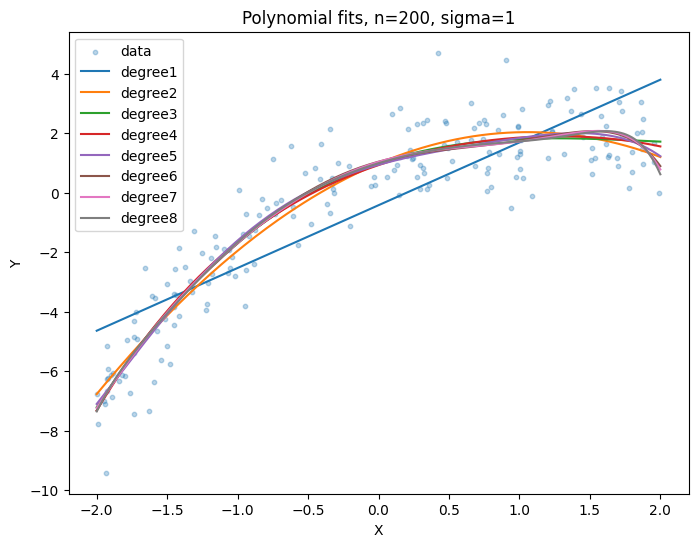

In [44]:
models = {}

for d in range(1, 9):
    poly = PolynomialFeatures(degree=d)
    Xd = poly.fit_transform(X.reshape(-1, 1))
    reg = LinearRegression().fit(Xd, Y)
    models[d] = (poly, reg)
    
x_grid = np.linspace(-2, 2, 200).reshape(-1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, s=10, alpha=0.3, label="data")

for d in range(1, 9):
    poly, reg = models[d]
    y_pred = reg.predict(poly.transform(x_grid))
    plt.plot(x_grid, y_pred, label = f"degree{d}")
    
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial fits, n=200, sigma=1")
plt.show()    


### b. Use 5-fold cross-validation to choose polynomial degree. 

In [45]:
# 5 fold 
kf = KFold(n_splits=5, shuffle=True, random_state=1)
cv_errors = {} # parse this

for d in range(1, 9):
    fold_mse = []
    for train_idx, val_idx, in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]
        
        poly = PolynomialFeatures(degree=d)
        Xd_train = poly.fit_transform(X_train.reshape(-1, 1))
        Xd_val = poly.transform(X_val.reshape(-1, 1))
        
        reg = LinearRegression().fit(Xd_train, Y_train)
        y_pred = reg.predict(Xd_val)
        fold_mse.append(np.mean((Y_val - y_pred)**2))
        
    cv_errors[d] = np.mean(fold_mse)
    
best_d = min(cv_errors, key=cv_errors.get)
print(cv_errors)
print(f"Best Degree: {best_d}")
        

{1: np.float64(2.447810711208664), 2: np.float64(1.0693699171952151), 3: np.float64(1.0258113447355404), 4: np.float64(1.0363129021963893), 5: np.float64(1.037905726833357), 6: np.float64(1.0444788393772968), 7: np.float64(1.0680554789803633), 8: np.float64(1.071971121781661)}
Best Degree: 3


### c. Repeat the experiment for two noise levels: $\sigma = 0.5$ and $\sigma = 2$. 

In [46]:
def experiment(sigma, seed=1):
    np.random.seed(seed)
    X = np.random.uniform(-2, 2, n)
    eps = np.random.normal(0, sigma, n)
    Y = 1 + 2*X - X**2 + eps
    
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    cv_errors = {}
    for d in range(1, 9):
        fold_mse = []
        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X[train_idx], X[val_idx]
            Y_train, Y_val = Y[train_idx], Y[val_idx]

            poly = PolynomialFeatures(degree=d)
            Xd_train = poly.fit_transform(X_train.reshape(-1, 1))
            Xd_val = poly.transform(X_val.reshape(-1, 1))

            reg = LinearRegression().fit(Xd_train, Y_train)
            y_pred = reg.predict(Xd_val)
            fold_mse.append(np.mean((Y_val - y_pred)**2))

        cv_errors[d] = np.mean(fold_mse)

    best_d = min(cv_errors, key=cv_errors.get)
    return X, Y, cv_errors, best_d


In [47]:
results = {}
for s in [0.5, 2.0]:
    X_s, Y_s, cv_errors_s, best_d_s = experiment(s)
    results[s] = {"X": X_s, "Y": Y_s, "cv_errors": cv_errors_s, "best_d": best_d_s}
    print(f"sigma={s}: best degree = {best_d_s}")
    print(f"cv_errors = {cv_errors_s}")


sigma=0.5: best degree = 3
cv_errors = {1: np.float64(1.7442124237700505), 2: np.float64(0.26734247929880367), 3: np.float64(0.25645283618388504), 4: np.float64(0.2590782255490973), 5: np.float64(0.259476431708339), 6: np.float64(0.2611197098443242), 7: np.float64(0.2670138697450913), 8: np.float64(0.2679927804454139)}
sigma=2.0: best degree = 3
cv_errors = {1: np.float64(5.450847181855126), 2: np.float64(4.2774796687808605), 3: np.float64(4.103245378942162), 4: np.float64(4.145251608785556), 5: np.float64(4.151622907333428), 6: np.float64(4.177915357509192), 7: np.float64(4.272221915921453), 8: np.float64(4.287884487126635)}


### Report the cross-validation errors in a table and plot the fitted curve for the selected model. 

sigma,0.5,1.0,2.0
degree,,,
1,1.7442,2.4478,5.4508
2,0.2673,1.0694,4.2775
3,0.2565,1.0258,4.1032
4,0.2591,1.0363,4.1453
5,0.2595,1.0379,4.1516
6,0.2611,1.0445,4.1779
7,0.2670,1.0681,4.2722
8,0.2680,1.0720,4.2879


Selected degree by 5-fold CV: {0.5: 3, 1.0: 3, 2.0: 3}


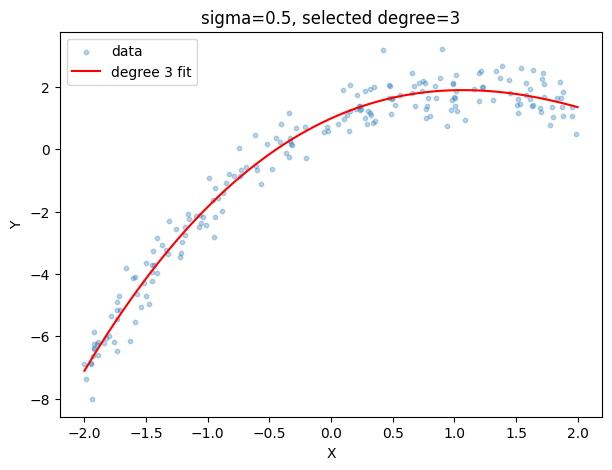

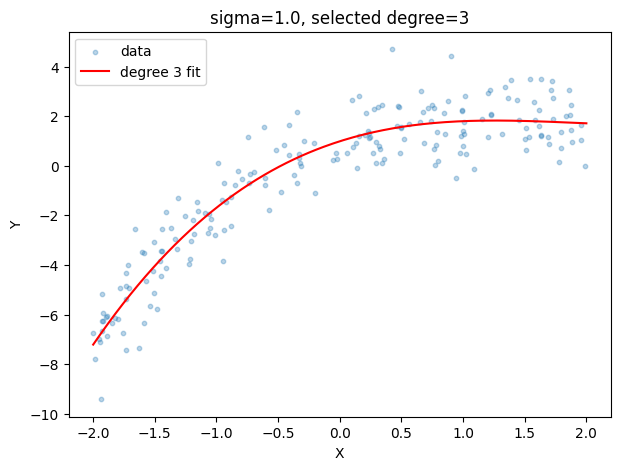

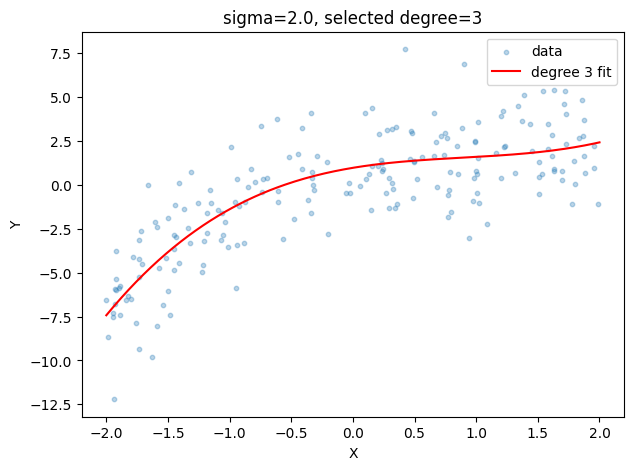

In [48]:
from IPython.display import display

# combine sigma=1 results (from part b) with sigma=0.5, 2.0 (from part c)
all_results = {
    0.5: results[0.5],
    1.0: {"X": X, "Y": Y, "cv_errors": cv_errors, "best_d": best_d},
    2.0: results[2.0],
}

# --- table of CV errors, degree x sigma ---
cv_table = pd.DataFrame({s: all_results[s]["cv_errors"] for s in sorted(all_results)})
cv_table.index.name = "degree"
cv_table.columns.name = "sigma"
display(cv_table.round(4))

best_degrees = {s: all_results[s]["best_d"] for s in sorted(all_results)}
print("Selected degree by 5-fold CV:", best_degrees)

# --- plot the fitted curve for the CV-selected model, one figure per sigma ---
x_grid = np.linspace(-2, 2, 200).reshape(-1, 1)

for s in sorted(all_results):
    Xs, Ys, best_d_s = all_results[s]["X"], all_results[s]["Y"], all_results[s]["best_d"]

    poly = PolynomialFeatures(degree=best_d_s)
    Xd = poly.fit_transform(Xs.reshape(-1, 1))
    reg = LinearRegression().fit(Xd, Ys)
    y_pred = reg.predict(poly.transform(x_grid))

    plt.figure(figsize=(7, 5))
    plt.scatter(Xs, Ys, s=10, alpha=0.3, label="data")
    plt.plot(x_grid, y_pred, color="red", label=f"degree {best_d_s} fit")
    plt.title(f"sigma={s}, selected degree={best_d_s}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()


### e. Discuss how the selected degree changes with the noise level.

5-fold CV selected **degree 3** at all three noise levels ($\sigma = 0.5, 1, 2$) — one above the true degree 2. That's expected: degree 1 is always rejected decisively (large error drop from degree 1→2 at every $\sigma$), but degree 2 vs. 3 is essentially a tie (~4% CV-error gap at every $\sigma$), since the true cubic coefficient is 0 and adding it costs almost no bias, only a little variance — noise from the random fold split is enough to tip the pick either way.

The minimum CV error tracks $\sigma^2$ almost exactly (always ~2.6% above the noise floor $\sigma^2$), so the estimation/variance cost of model selection scales proportionally with noise rather than growing faster. **Takeaway:** higher noise doesn't shift which degree CV picks here, but it flattens the CV curve near the minimum in relative terms, making the "correct" degree harder to pin down confidently as $\sigma$ grows.
